# CreditSense Task A: Office Baseline Classifier Port

This notebook ports the highest-scoring Task A classifier workflow from
`office_baseline (1) 1.ipynb` into the CreditSense project.

Pipeline:
- `AutoFeatureEngineer`
- column-wise preprocessing with median imputation, scaling, and one-hot encoding
- tuned `XGBClassifier` and `LGBMClassifier`
- weighted soft-voting ensemble
- native-categorical `CatBoostClassifier`
- stacked logistic meta-learner on concatenated CatBoost and voter probabilities

The notebook overwrites `submission.csv` by replacing only the `RiskTier`
column while preserving the existing `InterestRate` column when available.


In [1]:
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from pandas.errors import PerformanceWarning
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.ensemble import VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=PerformanceWarning)
np.random.seed(42)
random.seed(42)

TRAIN_PATH = Path("creditsense-ai1215/credit_train.csv")
TEST_PATH = Path("creditsense-ai1215/credit_test.csv")
SAMPLE_SUBMISSION_PATH = Path("creditsense-ai1215/sample_submission.csv")
SUBMISSION_PATH = Path("submission.csv")

print("Libraries loaded.")


Libraries loaded.


In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

X = train.drop(columns=["RiskTier", "InterestRate"])
y = train["RiskTier"].astype(int)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print()
print("RiskTier distribution:")
print(y.value_counts().sort_index().to_string())


Train shape: (35000, 57)
Test shape:  (15000, 55)

RiskTier distribution:
RiskTier
0    6724
1    7283
2    6998
3    6812
4    7183


Tuning XGBoost...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


Best XGB: {'xgb__subsample': 0.8, 'xgb__n_estimators': 600, 'xgb__min_child_weight': 5, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.03, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.8, 'feat__top_k_interactions': 8} CV: 0.78154

Tuning LightGBM...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18093
[LightGBM] [Info] Number of data points in the train set: 28000, number of used features: 169
[LightGBM] [Info] Start training from score -1.649702
[LightGBM] [Info] Start training from score -1.569702
[LightGBM] [Info] Start training from score -1.609795
[LightGBM] [Info] Start training from score -1.636589
[LightGBM] [Info] Start training from score -1.583701


Best LGBM: {'lgb__subsample': 0.8, 'lgb__num_leaves': 31, 'lgb__n_estimators': 500, 'lgb__min_child_samples': 10, 'lgb__learning_rate': 0.08, 'lgb__colsample_bytree': 1.0, 'feat__top_k_interactions': 6} CV: 0.78629


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21388
[LightGBM] [Info] Number of data points in the train set: 22400, number of used features: 182
[LightGBM] [Info] Start training from score -1.649516
[LightGBM] [Info] Start training from score -1.569616
[LightGBM] [Info] Start training from score -1.609884
[LightGBM] [Info] Start training from score -1.636589
[LightGBM] [Info] Start training from score -1.583875
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18073
[LightGBM] [Info] Number of data points in the train set: 22400, number of used features: 169
[LightGBM] [Info] St


Validation Accuracy (Weighted XGB+LGB): 0.79043

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1345
           1       0.69      0.71      0.70      1456
           2       0.72      0.69      0.70      1400
           3       0.77      0.82      0.80      1362
           4       0.95      0.92      0.93      1437

    accuracy                           0.79      7000
   macro avg       0.79      0.79      0.79      7000
weighted avg       0.79      0.79      0.79      7000



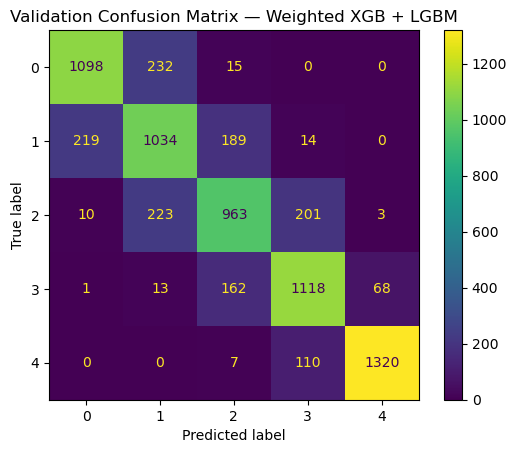

In [3]:
class AutoFeatureEngineer(BaseEstimator, TransformerMixin):
    '''
    - Remembers training schema & types
    - Adds: numeric squares + limited pairwise interactions among top-variance numeric cols
    - Adds: categorical frequency encodings
    '''
    def __init__(self, top_k_interactions=8, add_squares=True, add_interactions=True, add_cat_freq=True):
        self.top_k_interactions = top_k_interactions
        self.add_squares = add_squares
        self.add_interactions = add_interactions
        self.add_cat_freq = add_cat_freq

    def fit(self, X, y=None):
        X = X.copy()
        self._train_cols_ = X.columns.tolist()
        self._num_cols_ = X.select_dtypes(include=[np.number]).columns.tolist()
        self._cat_cols_ = [c for c in self._train_cols_ if c not in self._num_cols_]

        if self.add_interactions and len(self._num_cols_) > 1:
            variances = X[self._num_cols_].var().sort_values(ascending=False)
            self._top_num_for_inter_ = variances.index[:min(self.top_k_interactions, len(variances))].tolist()
        else:
            self._top_num_for_inter_ = []

        self._cat_freq_maps_ = {}
        if self.add_cat_freq and len(self._cat_cols_) > 0:
            n = len(X)
            for col in self._cat_cols_:
                freq = X[col].astype(str).value_counts(dropna=False) / n
                self._cat_freq_maps_[col] = freq.to_dict()
        return self

    def _align_schema_and_types(self, X):
        for col in self._train_cols_:
            if col not in X.columns:
                X[col] = np.nan
        for col in self._num_cols_:
            X[col] = pd.to_numeric(X[col], errors="coerce")
        for col in self._cat_cols_:
            X[col] = X[col].astype(str).fillna("")
        return X[self._train_cols_]

    def transform(self, X):
        X = X.copy()
        X = self._align_schema_and_types(X)
        engineered = {}

        if self.add_squares and len(self._num_cols_) > 0:
            for col in self._num_cols_:
                engineered[f"{col}__sq"] = X[col] * X[col]

        if self.add_interactions and len(self._top_num_for_inter_) > 1:
            cols = self._top_num_for_inter_
            for i in range(len(cols)):
                for j in range(i + 1, len(cols)):
                    c1, c2 = cols[i], cols[j]
                    engineered[f"{c1}__x__{c2}"] = X[c1] * X[c2]

        if self.add_cat_freq and len(self._cat_cols_) > 0:
            for col in self._cat_cols_:
                fmap = self._cat_freq_maps_.get(col, {})
                engineered[f"{col}__freq"] = X[col].map(fmap).fillna(0.0)

        if engineered:
            X = pd.concat([X, pd.DataFrame(engineered, index=X.index)], axis=1)
        return X


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

numeric_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])
categorical_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pre, selector(dtype_include=np.number)),
        ("cat", categorical_pre, selector(dtype_include=object)),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=1,
    random_state=42,
)
lgb = LGBMClassifier(
    objective="multiclass",
    n_jobs=1,
    random_state=42,
)

xgb_pipe = Pipeline([("feat", AutoFeatureEngineer()), ("prep", preprocessor), ("xgb", xgb)])
lgb_pipe = Pipeline([("feat", AutoFeatureEngineer()), ("prep", preprocessor), ("lgb", lgb)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_space = {
    "feat__top_k_interactions": [6, 8, 10],
    "xgb__n_estimators": [400, 600, 900],
    "xgb__max_depth": [6, 8, 10],
    "xgb__learning_rate": [0.03, 0.05, 0.08],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__min_child_weight": [1, 3, 5],
    "xgb__gamma": [0, 0.1],
}

lgb_space = {
    "feat__top_k_interactions": [6, 8, 10],
    "lgb__n_estimators": [500, 800, 1100],
    "lgb__learning_rate": [0.03, 0.05, 0.08],
    "lgb__num_leaves": [31, 63, 95],
    "lgb__min_child_samples": [10, 20, 30],
    "lgb__subsample": [0.8, 1.0],
    "lgb__colsample_bytree": [0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_space,
    n_iter=5,
    cv=cv,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    verbose=1,
)
lgb_search = RandomizedSearchCV(
    lgb_pipe,
    lgb_space,
    n_iter=5,
    cv=cv,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    verbose=1,
)

print("Tuning XGBoost...")
xgb_search.fit(X_train, y_train)
print("Best XGB:", xgb_search.best_params_, "CV:", f"{xgb_search.best_score_:.5f}")

print("\nTuning LightGBM...")
lgb_search.fit(X_train, y_train)
print("Best LGBM:", lgb_search.best_params_, "CV:", f"{lgb_search.best_score_:.5f}")

best_xgb = xgb_search.best_estimator_
best_lgb = lgb_search.best_estimator_

w_xgb = xgb_search.best_score_
w_lgb = lgb_search.best_score_
if w_xgb > w_lgb:
    w_xgb *= 1.10
else:
    w_lgb *= 1.10

voter = VotingClassifier(
    estimators=[("xgb", best_xgb), ("lgb", best_lgb)],
    voting="soft",
    weights=[w_xgb, w_lgb],
    n_jobs=-1,
)
voter.fit(X_train, y_train)

voter_val_pred = voter.predict(X_val)
voter_val_acc = accuracy_score(y_val, voter_val_pred)
print(f"\nValidation Accuracy (Weighted XGB+LGB): {voter_val_acc:.5f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, voter_val_pred))

ConfusionMatrixDisplay.from_predictions(y_val, voter_val_pred)
plt.title("Validation Confusion Matrix — Weighted XGB + LGBM")
plt.show()


In [4]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]


def to_catboost_df(df_base: pd.DataFrame) -> pd.DataFrame:
    df = df_base.copy()
    df = df.reindex(columns=X.columns, fill_value=np.nan)
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in cat_cols:
        df[c] = df[c].astype("object").fillna("Missing").astype(str)
    return df


X_train_cb = to_catboost_df(X_train)
X_val_cb = to_catboost_df(X_val)
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

cat = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=1200,
    learning_rate=0.06,
    depth=6,
    l2_leaf_reg=3.0,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    rsm=0.8,
    random_seed=42,
    od_type="Iter",
    od_wait=50,
    thread_count=-1,
    verbose=False,
    allow_writing_files=False,
)

t0 = time.time()
cat.fit(X_train_cb, y_train, cat_features=cat_idx, eval_set=(X_val_cb, y_val), verbose=False)
print("CatBoost best_iter:", cat.get_best_iteration(), "| fit secs:", round(time.time() - t0, 1))

proba_cat_val = cat.predict_proba(X_val_cb)
proba_voter_val = voter.predict_proba(X_val)
X_meta_val = np.hstack([proba_cat_val, proba_voter_val])

X_meta_tr, X_meta_ho, y_meta_tr, y_meta_ho = train_test_split(
    X_meta_val,
    y_val,
    test_size=0.25,
    stratify=y_val,
    random_state=42,
)

meta = LogisticRegression(max_iter=2000, multi_class="multinomial", n_jobs=-1)
meta.fit(X_meta_tr, y_meta_tr)
ho_pred = meta.predict(X_meta_ho)
print("Meta holdout accuracy:", f"{accuracy_score(y_meta_ho, ho_pred):.5f}")

meta.fit(X_meta_val, y_val)
stacked_val_pred = np.argmax(meta.predict_proba(X_meta_val), axis=1)
stacked_val_acc = accuracy_score(y_val, stacked_val_pred)
print("Stacked validation accuracy (refit meta on full val):", f"{stacked_val_acc:.5f}")
print("\nStacked validation classification report:")
print(classification_report(y_val, stacked_val_pred))

test_cb = to_catboost_df(test)
proba_cat_test = cat.predict_proba(test_cb)
test_for_voter = test.reindex(columns=X.columns, fill_value=np.nan)
proba_voter_test = voter.predict_proba(test_for_voter)
X_meta_test = np.hstack([proba_cat_test, proba_voter_test])
pred_test = np.argmax(meta.predict_proba(X_meta_test), axis=1)

interest_rate_source = "sample submission"
interest_rate_values = sample_submission["InterestRate"].to_numpy()
if SUBMISSION_PATH.exists():
    existing_submission = pd.read_csv(SUBMISSION_PATH)
    expected_cols = ["Id", "RiskTier", "InterestRate"]
    if list(existing_submission.columns) == expected_cols and len(existing_submission) == len(pred_test):
        interest_rate_values = existing_submission["InterestRate"].to_numpy()
        interest_rate_source = "existing submission.csv"

submission = pd.DataFrame({
    "Id": sample_submission["Id"],
    "RiskTier": pred_test.astype(int),
    "InterestRate": interest_rate_values,
})
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"\nSaved {SUBMISSION_PATH} using RiskTier predictions from the stacked classifier.")
print(f"InterestRate column preserved from: {interest_rate_source}")
print("\nSubmission preview:")
print(submission.head().to_string(index=False))


CatBoost best_iter: 1199 | fit secs: 55.6


Meta holdout accuracy: 0.80800
Stacked validation accuracy (refit meta on full val): 0.82429

Stacked validation classification report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1345
           1       0.74      0.76      0.75      1456
           2       0.76      0.76      0.76      1400
           3       0.82      0.84      0.83      1362
           4       0.95      0.93      0.94      1437

    accuracy                           0.82      7000
   macro avg       0.83      0.82      0.83      7000
weighted avg       0.83      0.82      0.82      7000




Saved submission.csv using RiskTier predictions from the stacked classifier.
InterestRate column preserved from: existing submission.csv

Submission preview:
 Id  RiskTier  InterestRate
  0         2          5.80
  1         0          6.18
  2         2          6.53
  3         3          6.93
  4         4         17.63
